In [1]:
from tensorflow.keras.datasets import boston_housing

(X_train, y_train), (X_test, y_test) = boston_housing.load_data()

In [3]:
X_train.shape

(404, 13)

In [6]:
y_train.shape

(404,)

In [8]:
import pandas as pd
X_train_df = pd.DataFrame(X_train)

In [12]:
X_train_df.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12
0,1.23247,0.0,8.14,0.0,0.538,6.142,91.7,3.9769,4.0,307.0,21.0,396.90,18.72
1,0.02177,82.5,2.03,0.0,0.415,7.610,15.7,6.2700,2.0,348.0,14.7,395.38,3.11
2,4.89822,0.0,18.10,0.0,0.631,4.970,100.0,1.3325,24.0,666.0,20.2,375.52,3.26
3,0.03961,0.0,5.19,0.0,0.515,6.037,34.5,5.9853,5.0,224.0,20.2,396.90,8.01
4,3.69311,0.0,18.10,0.0,0.713,6.376,88.4,2.5671,24.0,666.0,20.2,391.43,14.65


In [16]:
X_train_df.describe()

,0,1,2,3,4,5,6,7,8,9,10,11,12
count,404.000000,404.000000,404.000000,404.000000,404.000000,404.000000,404.000000,404.000000,404.000000,404.000000,404.000000,404.000000,404.000000
mean,3.745111,11.480198,11.104431,0.061881,0.557356,6.267082,69.010644,3.740271,9.440594,405.898515,18.475990,354.783168,12.740817
std,9.240734,23.767711,6.811308,0.241238,0.117293,0.709788,27.940665,2.030215,8.698360,166.374543,2.200382,94.111148,7.254545
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,188.000000,12.600000,0.320000,1.730000
25%,0.081437,0.000000,5.130000,0.000000,0.453000,5.874750,45.475000,2.077100,4.000000,279.000000,17.225000,374.672500,6.890000
50%,0.268880,0.000000,9.690000,0.000000,0.538000,6.198500,78.500000,3.142300,5.000000,330.000000,19.100000,391.250000,11.395000
75%,3.674808,12.500000,18.100000,0.000000,0.631000,6.609000,94.100000,5.118000,24.000000,666.000000,20.200000,396.157500,17.092500
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.725000,100.000000,10.710300,24.000000,711.000000,22.000000,396.900000,37.970000


In [18]:
# Normalización
promedio = X_train.mean(axis=0)
X_train -= promedio

DS = X_train.std(axis=0)
X_train /=DS

X_test-=promedio
X_test/=DS

In [32]:
from tensorflow import keras

# crea la arquitectura del modelo
# La red devuelve un valor numérico
def crear_modelo():
    modelo = keras.Sequential([
        keras.layers.Dense(64, activation="relu"),
        keras.layers.Dense(64, activation="relu"),
        keras.layers.Dense(1),
    ])
    
    modelo.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])
    return modelo

In [36]:
modelo_regresion = crear_modelo()
modelo_regresion.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [42]:
# Entrenamiento simple
historial_entrenamiento_simple = modelo_regresion.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=10,
    validation_data=(X_test, y_test))

Epoch 1/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 524.6514 - mae: 20.7987 - val_loss: 342.6613 - val_mae: 16.3331
Epoch 2/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 740us/step - loss: 274.7798 - mae: 13.8385 - val_loss: 120.8278 - val_mae: 9.1414
Epoch 3/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 765us/step - loss: 95.8264 - mae: 7.4194 - val_loss: 60.0161 - val_mae: 6.0282
Epoch 4/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 749us/step - loss: 38.6981 - mae: 4.6111 - val_loss: 34.3981 - val_mae: 4.5554
Epoch 5/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 697us/step - loss: 32.9784 - mae: 3.9186 - val_loss: 26.0968 - val_mae: 3.9935
Epoch 6/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 700us/step - loss: 23.0986 - mae: 3.1660 - val_loss: 22.4998 - val_mae: 3.7165
Epoch 7/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 671us/step - loss: 17.6664 - mae: 2.9401 - val_loss: 20.8005 - val_mae: 3.5763
Epoch 8/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 630us/step - loss: 17.3837 - mae: 2.9323 - val_loss: 20.5421 - val_mae: 3.3857
Epoch 9/100
41/41 ━━━━━━━━━

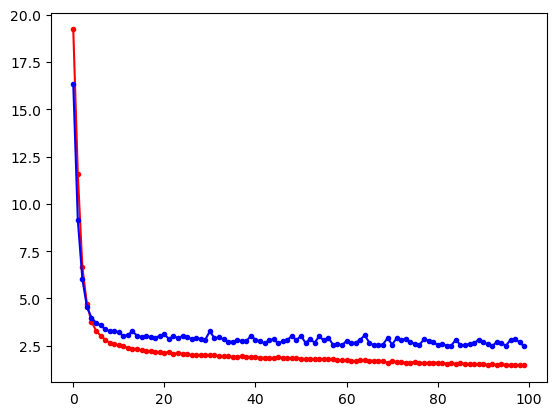

In [44]:
import matplotlib.pyplot as plt

# Grafica de evolución del entrenamiento
plt.plot(historial_entrenamiento_simple.history["mae"], "r", marker='.', label = "MAE X_train")
plt.plot(historial_entrenamiento_simple.history["val_mae"], "b", marker='.', label = "MAE X_val")
plt.show();

In [50]:
# Entrenamiento con kFold CrossValidation
import numpy as np

#Configuración de kFold
k = 4
tajada_muestras_validacion = len(X_train)//k

epocas = 100
metricas = []

#Comenzar el entrenamiento por partes
for i in range(k):
    print(f"> Procesando k Fold N{i}")
    X_val = X_train[i * tajada_muestras_validacion: (i+1) * tajada_muestras_validacion]
    y_val = y_train[i * tajada_muestras_validacion: (i+1) * tajada_muestras_validacion]
    
    X_train_parcial = np.concatenate(
        [X_train[: i * tajada_muestras_validacion],
        X_train[(i+1) * tajada_muestras_validacion:]], axis=0)
    y_train_parcial = np.concatenate(
        [y_train[: i * tajada_muestras_validacion],
        y_train[(i+1) * tajada_muestras_validacion:]], axis=0)
    
    modelo_regresion_kfold = crear_modelo()
    historial_entrenamiento_kfold = modelo_regresion_kfold.fit(
        X_train_parcial,
        y_train_parcial,
        epochs = epocas,
        batch_size=10)
    val_mse, val_mae = modelo_regresion_kfold.evaluate(X_val, y_val)
    metricas.append(val_mae)

> Procesando k Fold N0
Epoch 1/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 393us/step - loss: 545.8700 - mae: 21.1581 
Epoch 2/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 290us/step - loss: 338.2825 - mae: 15.8581
Epoch 3/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 552us/step - loss: 127.8314 - mae: 9.1000
Epoch 4/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 468us/step - loss: 53.0485 - mae: 5.4530
Epoch 5/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 472us/step - loss: 29.3870 - mae: 4.2533
Epoch 6/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 506us/step - loss: 24.2128 - mae: 3.7669
Epoch 7/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 435us/step - loss: 21.9199 - mae: 3.1928
Epoch 8/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 405us/step - loss: 19.0432 - mae: 3.1678
Epoch 9/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 448us/step - loss: 19.9655 - mae: 3.2127
Epoch 10/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 435us/step - loss: 17.8444 - mae: 3.0717
Epoch 11/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 431us/step - loss: 15.4200 - mae: 2.8153
Epoch 12/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 360us/step - 

In [52]:
#Configuración de kFold
k = 4
tajada_muestras_validacion = len(X_train)//k

epocas = 100
metricas = []

#Comenzar el entrenamiento por partes
for i in range(k):
    print(f"> Procesando k Fold N{i}")
    X_val = X_train[i * tajada_muestras_validacion: (i+1) * tajada_muestras_validacion]
    y_val = y_train[i * tajada_muestras_validacion: (i+1) * tajada_muestras_validacion]
    
    X_train_parcial = np.concatenate(
        [X_train[: i * tajada_muestras_validacion],
        X_train[(i+1) * tajada_muestras_validacion:]], axis=0)
    y_train_parcial = np.concatenate(
        [y_train[: i * tajada_muestras_validacion],
        y_train[(i+1) * tajada_muestras_validacion:]], axis=0)
    
    modelo_regresion_kfold = crear_modelo()
    historial_entrenamiento_kfold = modelo_regresion_kfold.fit(
        X_train_parcial,
        y_train_parcial,
        epochs = epocas,
        batch_size=10,
        validation_data = (X_val, y_val)
    )
    val_mse, val_mae = modelo_regresion_kfold.evaluate(X_val, y_val)
    historial_mae = historial_entrenamiento_kfold.history["val_mae"]
    metricas.append(historial_mae)

> Procesando k Fold N0
Epoch 1/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 505.2156 - mae: 20.6909 - val_loss: 304.5500 - val_mae: 14.7662
Epoch 2/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 240.5672 - mae: 13.3918 - val_loss: 94.3458 - val_mae: 7.0941
Epoch 3/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 80.3061 - mae: 6.9215 - val_loss: 42.9429 - val_mae: 4.4414
Epoch 4/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 37.1789 - mae: 4.6326 - val_loss: 32.9894 - val_mae: 3.8772
Epoch 5/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 917us/step - loss: 26.5515 - mae: 3.7327 - val_loss: 27.8773 - val_mae: 3.4847
Epoch 6/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 737us/step - loss: 20.9891 - mae: 3.4839 - val_loss: 24.0458 - val_mae: 3.2215
Epoch 7/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 727us/step - loss: 21.5698 - mae: 3.3010 - val_loss: 21.1451 - val_mae: 2.9974
Epoch 8/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 697us/step - loss: 17.6232 - mae: 2.9427 - val_loss: 18.9166 - val_mae: 2.8317
Epoch 9/100

In [60]:
promedio_mae_historico = [np.mean([x[i] for x in metricas]) for i in range(epocas)]

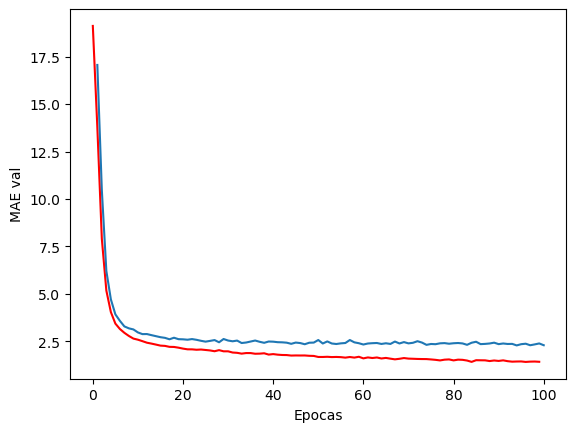

In [62]:
#Gráficas de evolución de entrenamiento con kFold
plt.plot(historial_entrenamiento_kfold.history["mae"], "r", label='MAE X_train')
plt.plot(range(1, len(promedio_mae_historico)+1), promedio_mae_historico)
plt.xlabel("Epocas")
plt.ylabel("MAE val")
plt.show()

In [70]:
# Incorporar Regularización

from tensorflow.keras import regularizers

# crea la arquitectura del modelo
# La red devuelve un valor numérico
def crear_modelo_l1():
    modelo = keras.Sequential([
        keras.layers.Dense(64, activation="relu", kernel_regularizer = regularizers.l1(0.001)),
        keras.layers.Dense(64, activation="relu", kernel_regularizer = regularizers.l1(0.001)),
        keras.layers.Dense(1),
    ])
    
    modelo.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])
    return modelo

Epoch 1/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 503.5098 - mae: 20.3823 - val_loss: 331.1027 - val_mae: 16.1175
Epoch 2/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 607us/step - loss: 254.3558 - mae: 13.6795 - val_loss: 94.6767 - val_mae: 8.2074
Epoch 3/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 777us/step - loss: 68.5752 - mae: 6.3640 - val_loss: 41.5551 - val_mae: 4.8576
Epoch 4/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 596us/step - loss: 29.5570 - mae: 4.0102 - val_loss: 28.7870 - val_mae: 4.1395
Epoch 5/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 584us/step - loss: 30.7727 - mae: 3.5868 - val_loss: 25.1149 - val_mae: 3.9031
Epoch 6/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 567us/step - loss: 20.6887 - mae: 3.1199 - val_loss: 24.4295 - val_mae: 3.6863
Epoch 7/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 601us/step - loss: 17.0249 - mae: 2.8672 - val_loss: 24.8907 - val_mae: 3.6728
Epoch 8/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 597us/step - loss: 15.6136 - mae: 2.8447 - val_loss: 22.6437 - val_mae: 3.4446
Epoch 9/100
41/41 ━━━━━━━━━━

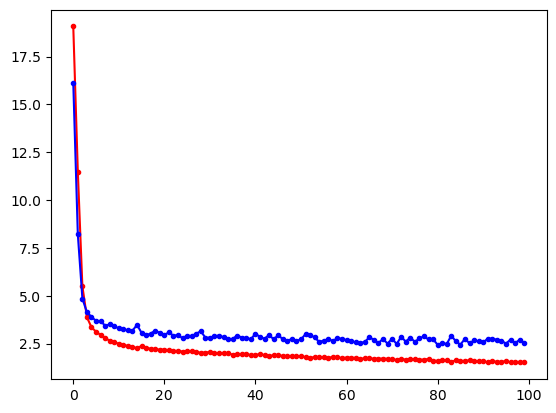

In [72]:
modelo_l1 = crear_modelo_l1()
entrenamiento_l1 = modelo_l1.fit(X_train, y_train, epochs=100, batch_size=10, validation_data=(X_test,y_test))
plt.plot(entrenamiento_l1.history["mae"], 'r', marker='.', label='MAE X_train')
plt.plot(entrenamiento_l1.history["val_mae"], 'b', marker='.', label='MAE Val')
plt.show();

In [74]:
# Incorporar Regularización

from tensorflow.keras import regularizers

# crea la arquitectura del modelo
# La red devuelve un valor numérico
def crear_modelo_l2():
    modelo = keras.Sequential([
        keras.layers.Dense(64, activation="relu", kernel_regularizer = regularizers.l2(0.001)),
        keras.layers.Dense(64, activation="relu", kernel_regularizer = regularizers.l2(0.001)),
        keras.layers.Dense(1),
    ])
    
    modelo.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])
    return modelo

Epoch 1/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 531.8593 - mae: 21.1475 - val_loss: 333.6594 - val_mae: 16.2647
Epoch 2/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 691us/step - loss: 276.9528 - mae: 14.1921 - val_loss: 131.5242 - val_mae: 9.2965
Epoch 3/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 724us/step - loss: 90.8498 - mae: 7.0723 - val_loss: 64.1191 - val_mae: 6.1256
Epoch 4/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 591us/step - loss: 44.4570 - mae: 4.9859 - val_loss: 39.9203 - val_mae: 4.9505
Epoch 5/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 631us/step - loss: 36.4856 - mae: 4.2215 - val_loss: 28.8226 - val_mae: 4.2198
Epoch 6/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 684us/step - loss: 26.3593 - mae: 3.4156 - val_loss: 27.6796 - val_mae: 4.1674
Epoch 7/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 657us/step - loss: 20.8701 - mae: 3.1776 - val_loss: 24.8080 - val_mae: 3.8854
Epoch 8/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 727us/step - loss: 20.2376 - mae: 3.0024 - val_loss: 22.6717 - val_mae: 3.6235
Epoch 9/100
41/41 ━━━━━━━━━

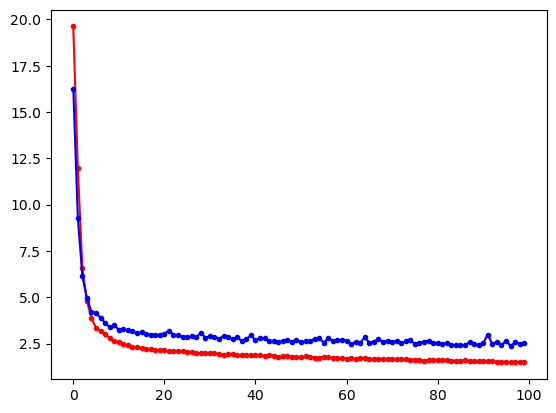

In [76]:
modelo_l2 = crear_modelo_l2()
entrenamiento_l2 = modelo_l2.fit(X_train, y_train, epochs=100, batch_size=10, validation_data=(X_test,y_test))
plt.plot(entrenamiento_l2.history["mae"], 'r', marker='.', label='MAE X_train')
plt.plot(entrenamiento_l2.history["val_mae"], 'b', marker='.', label='MAE Val')
plt.show();

In [78]:
# Incorporar Regularización

from tensorflow.keras import regularizers

# crea la arquitectura del modelo
# La red devuelve un valor numérico
def crear_modelo_l1_l2():
    modelo = keras.Sequential([
        keras.layers.Dense(64, activation="relu", kernel_regularizer = regularizers.l1_l2(0.001)),
        keras.layers.Dense(64, activation="relu", kernel_regularizer = regularizers.l1_l2(0.001)),
        keras.layers.Dense(1),
    ])
    
    modelo.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])
    return modelo

Epoch 1/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 526.4814 - mae: 20.9379 - val_loss: 334.8050 - val_mae: 16.3022
Epoch 2/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 661us/step - loss: 228.0886 - mae: 13.0823 - val_loss: 84.0280 - val_mae: 7.6667
Epoch 3/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 668us/step - loss: 62.0699 - mae: 5.8376 - val_loss: 38.1908 - val_mae: 4.7796
Epoch 4/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 624us/step - loss: 29.1998 - mae: 3.9259 - val_loss: 28.3450 - val_mae: 3.9963
Epoch 5/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 728us/step - loss: 22.6666 - mae: 3.2514 - val_loss: 26.0716 - val_mae: 3.8766
Epoch 6/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 560us/step - loss: 21.2199 - mae: 3.1447 - val_loss: 24.2193 - val_mae: 3.5795
Epoch 7/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 553us/step - loss: 18.9375 - mae: 2.9761 - val_loss: 24.4848 - val_mae: 3.5143
Epoch 8/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 714us/step - loss: 17.2617 - mae: 2.8810 - val_loss: 25.6535 - val_mae: 3.5478
Epoch 9/100
41/41 ━━━━━━━━━━

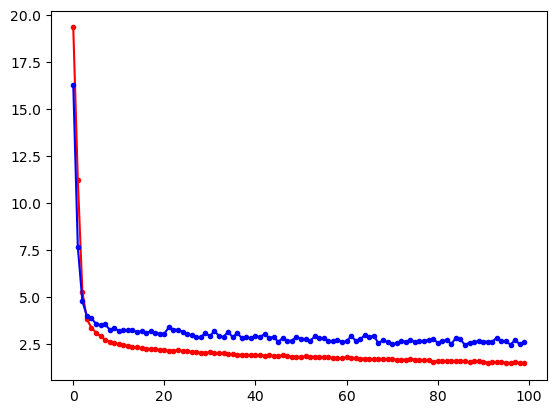

In [80]:
modelo_l1_l2 = crear_modelo_l1_l2()
entrenamiento_l1_l2 = modelo_l1_l2.fit(X_train, y_train, epochs=100, batch_size=10, validation_data=(X_test,y_test))
plt.plot(entrenamiento_l1_l2.history["mae"], 'r', marker='.', label='MAE X_train')
plt.plot(entrenamiento_l1_l2.history["val_mae"], 'b', marker='.', label='MAE Val')
plt.show();

In [88]:
# Incorporar Dropout

# crea la arquitectura del modelo
# La red devuelve un valor numérico
def crear_modelo_drop():
    modelo = keras.Sequential([
        keras.layers.Dense(64, activation="relu"),
        keras.layers.Dropout(0.2),
        keras.layers.Dense(64, activation="relu"),
        keras.layers.Dropout(0.2),
        keras.layers.Dense(1),
    ])
    
    modelo.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])
    return modelo

Epoch 1/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 518.0204 - mae: 21.0287 - val_loss: 349.1601 - val_mae: 16.6269
Epoch 2/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 660us/step - loss: 284.8960 - mae: 14.1804 - val_loss: 120.2518 - val_mae: 8.9889
Epoch 3/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 719us/step - loss: 102.6577 - mae: 7.6359 - val_loss: 56.8690 - val_mae: 5.8376
Epoch 4/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 672us/step - loss: 52.7661 - mae: 5.3078 - val_loss: 34.1744 - val_mae: 4.6326
Epoch 5/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 796us/step - loss: 51.6066 - mae: 4.9425 - val_loss: 28.1965 - val_mae: 4.1142
Epoch 6/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 703us/step - loss: 33.6192 - mae: 4.0118 - val_loss: 23.3523 - val_mae: 3.7694
Epoch 7/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 899us/step - loss: 27.7852 - mae: 3.8337 - val_loss: 23.7756 - val_mae: 3.8182
Epoch 8/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 806us/step - loss: 27.0442 - mae: 3.8490 - val_loss: 22.6826 - val_mae: 3.5966
Epoch 9/100
41/41 ━━━━━━━

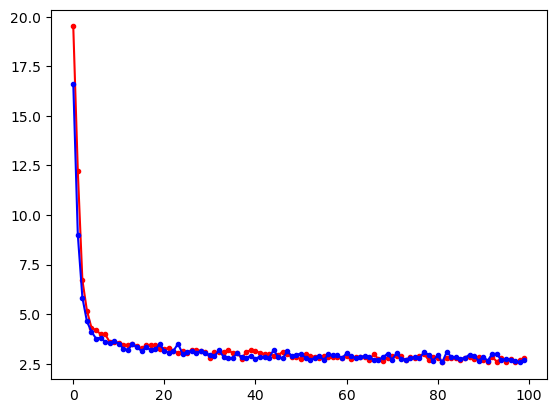

In [90]:
modelo_drop = crear_modelo_drop()
entrenamiento_drop = modelo_drop.fit(X_train, y_train, epochs=100, batch_size=10, validation_data=(X_test,y_test))
plt.plot(entrenamiento_drop.history["mae"], 'r', marker='.', label='MAE X_train')
plt.plot(entrenamiento_drop.history["val_mae"], 'b', marker='.', label='MAE Val')
plt.show();